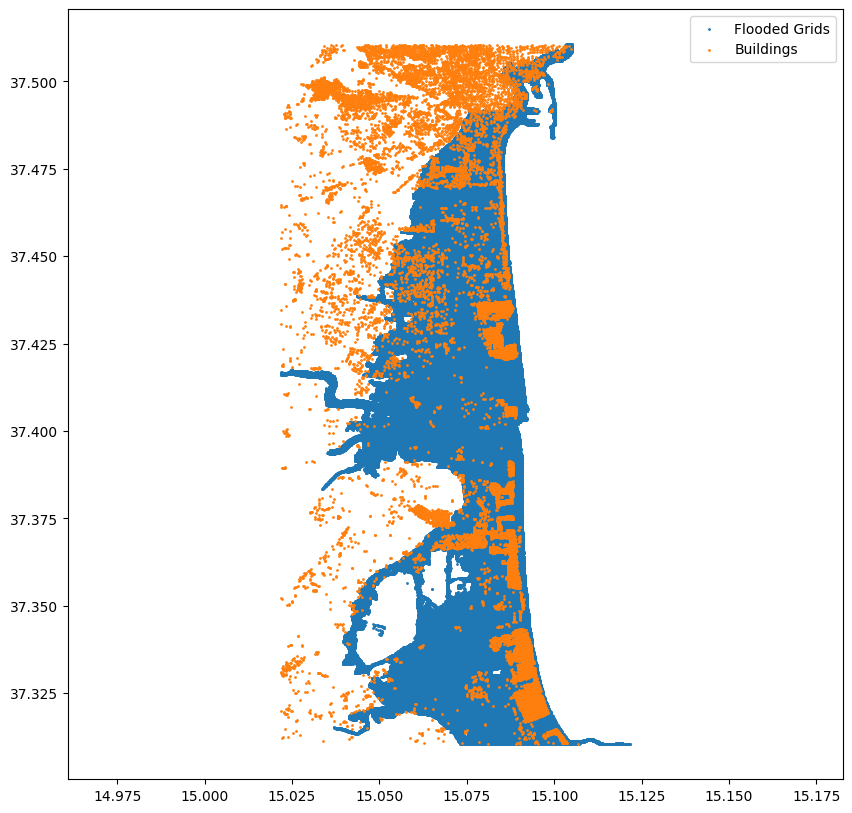

HDF5 file created successfully


In [1]:
import os
import sys
# import geopandas as gpd
import pandas as pd
import numpy as np
import h5py
import matplotlib.pyplot as plt
from openquake.hazardlib import site
from openquake.baselib import hdf5

#read geopackage file with building polygons
haz_path = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/processed/lat_lon_idx_CT_892.txt'
ex_path = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/risk/loss/building_exposure.csv'
flooded_grids = pd.read_csv(haz_path, sep=',', header=None)
building_exposure = pd.read_csv(ex_path, sep=',')

flooded_grids.columns = ['m', 'n', 'lat', 'lon']

#plot the flooded grids
plt.figure(figsize=(10,10))
plt.scatter(flooded_grids['lon'], flooded_grids['lat'], s=1,label='Flooded Grids')
plt.scatter(building_exposure['Lon'], building_exposure['Lat'], s=1, label='Buildings')
plt.legend()
plt.axis('equal')
plt.show()

#save hazard as lat,lon,intensity
flooded_grids['intensity'] = 3
flooded_grids = flooded_grids[['lat', 'lon', 'intensity']]
flooded_grids.to_csv('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/risk/hazard/tsunami_depth.csv', sep=',', header=True, index=None)

#save calculation locations as lat,lon
sites = flooded_grids[['lon', 'lat']]
sites.to_csv('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/risk/loss/tsunami_sites.csv', sep=',', header=None, index=None)

#save tsunami scenario with depth per site info as rlzi,sid,eid,gmv_PGA
rlzi = 0
sid = np.arange(0, len(sites))
eid = 0
gmv_PGA = 3

tsunami_scenario = pd.DataFrame({'rlzi': rlzi, 'sid': sid, 'eid': eid, 'gmv_PGA': gmv_PGA})
tsunami_scenario.to_csv('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/risk/loss/tsunami_scenario.csv', sep=',', header=True, index=None)

#prepare hdf5 file with gmf_data and sitecol as groups
hdf5_file = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/risk/loss/tsunami_scenario.hdf5'

# site collection
haz_sitecol = site.SiteCollection.from_points(sites['lon'], sites['lat'],req_site_params = {})

with hdf5.File(hdf5_file, 'w') as hf:
    hf.create_group('gmf_data')
    hf.create_dataset('gmf_data/sid', data=tsunami_scenario['sid'],dtype='uint32')
    hf.create_dataset('gmf_data/eid', data=tsunami_scenario['eid'], dtype='uint32')
    hf.create_dataset('gmf_data/gmv_0', data=tsunami_scenario['gmv_PGA'], dtype='float32')
    hf['gmf_data'].attrs['__pdcolumns__'] = 'sid eid gmv_0'
    hf['gmf_data'].attrs['imts'] = 'PGA'
    hf['gmf_data'].attrs['num_events'] = 1
    hf['gmf_data'].attrs['investigation_time'] = 1
    hf['gmf_data'].attrs['effective_time'] = 1
    hf.create_group('sitecol')
    hf['sitecol'] = haz_sitecol
    hf.close()
print('HDF5 file created successfully')

Read processed np arrays from dask dataframe

In [ ]:
import numpy as np
import pandas as pd
from openquake.hazardlib import site
from openquake.baselib import hdf5

# true_non_zero_idx = np.load('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/risk/hazard/true_non_zero_idx.npy')
true_d = np.load('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/risk/hazard/true_d_dask.npy')
true_event_id = np.load('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/risk/hazard/event_id_true.npy')
true_site_id = np.load('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/risk/hazard/site_id_true.npy')

save as oq gmf_data in hdf5 format

In [4]:
sites_path = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/processed/lat_lon_idx_CT_892.txt'
sites = pd.read_csv(sites_path, sep=',', header=None)
sites.columns = ['m', 'n', 'lat', 'lon']
sites = sites[['lat', 'lon']]

# site collection
haz_sitecol = site.SiteCollection.from_points(sites['lon'], sites['lat'],req_site_params = {})


In [5]:
#prepare hdf5 file with gmf_data and sitecol as groups
hdf5_file = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/risk/loss/tsunami_prob_true.hdf5'

with hdf5.File(hdf5_file, 'w') as hf:
    hf.create_group('gmf_data')
    hf.create_dataset('gmf_data/sid', data=true_site_id,dtype='uint32')
    hf.create_dataset('gmf_data/eid', data=true_event_id, dtype='uint32')
    hf.create_dataset('gmf_data/gmv_0', data=true_d, dtype='float32')
    hf['gmf_data'].attrs['__pdcolumns__'] = 'sid eid gmv_0'
    hf['gmf_data'].attrs['imts'] = 'PGA'
    hf['gmf_data'].attrs['num_events'] = 53550
    hf['gmf_data'].attrs['investigation_time'] = 1
    hf['gmf_data'].attrs['effective_time'] = 1
    hf.create_group('sitecol')
    hf['sitecol'] = haz_sitecol
    hf.close()
print('HDF5 file created successfully')

HDF5 file created successfully


In [5]:
import numpy as np
import pandas as pd
from openquake.hazardlib import site
from openquake.baselib import hdf5

# mean, sigmaminus and sigmaplus 
type = ['mean', 'sigmaminus', 'sigmaplus']
for t in type:
    pred_d = np.load(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/risk/hazard/pred_d_dask_1658_{t}.npy')
    pred_event_id = np.load(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/risk/hazard/event_id_pred_1658_{t}.npy')
    pred_site_id = np.load(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/risk/hazard/site_id_pred_1658_{t}.npy')

    #prepare hdf5 file with gmf_data and sitecol as groups
    hdf5_file = f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/risk/loss/tsunami_prob_1658_{t}.hdf5'

    with hdf5.File(hdf5_file, 'w') as hf:
        hf.create_group('gmf_data')
        hf.create_dataset('gmf_data/sid', data=pred_site_id,dtype='uint32')
        hf.create_dataset('gmf_data/eid', data=pred_event_id, dtype='uint32')
        hf.create_dataset('gmf_data/gmv_0', data=pred_d, dtype='float32')
        hf['gmf_data'].attrs['__pdcolumns__'] = 'sid eid gmv_0'
        hf['gmf_data'].attrs['imts'] = 'PGA'
        hf['gmf_data'].attrs['num_events'] = 53550
        hf['gmf_data'].attrs['investigation_time'] = 1
        hf['gmf_data'].attrs['effective_time'] = 1
        hf.create_group('sitecol')
        hf['sitecol'] = haz_sitecol
        hf.close()
    print(f'HDF5 file created successfully for {t}')


HDF5 file created successfully for mean
HDF5 file created successfully for sigmaminus
HDF5 file created successfully for sigmaplus


In [8]:
train_size = ['892','1658','3454','7071']

for size in train_size:
    pred_d = np.load(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/risk/hazard/pred_d_dask_{size}.npy')
    pred_event_id = np.load(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/risk/hazard/event_id_pred_{size}.npy')
    pred_site_id = np.load(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/risk/hazard/site_id_pred_{size}.npy')

    #prepare hdf5 file with gmf_data and sitecol as groups
    hdf5_file = f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/risk/loss/tsunami_prob_{size}.hdf5'

    with hdf5.File(hdf5_file, 'w') as hf:
        hf.create_group('gmf_data')
        hf.create_dataset('gmf_data/sid', data=pred_site_id,dtype='uint32')
        hf.create_dataset('gmf_data/eid', data=pred_event_id, dtype='uint32')
        hf.create_dataset('gmf_data/gmv_0', data=pred_d, dtype='float32')
        hf['gmf_data'].attrs['__pdcolumns__'] = 'sid eid gmv_0'
        hf['gmf_data'].attrs['imts'] = 'PGA'
        hf['gmf_data'].attrs['num_events'] = 53550
        hf['gmf_data'].attrs['investigation_time'] = 1
        hf['gmf_data'].attrs['effective_time'] = 1
        hf.create_group('sitecol')
        hf['sitecol'] = haz_sitecol
        hf.close()
    print('HDF5 file created successfully')

HDF5 file created successfully
HDF5 file created successfully
HDF5 file created successfully
HDF5 file created successfully


Check hdf5 file

In [ ]:
import numpy as np
import pandas as pd
from openquake.hazardlib import site
from openquake.baselib import hdf5

file = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/risk/loss/tsunami_prob.hdf5'

with hdf5.File(file, 'r') as hf:
    gmf_data = hf['gmf_data\eid']
    print(gmf_data)

    # hf.close()

Generate with loop csv

In [ ]:
true_d = np.load('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/CT/PTHA/true_d_53550.npy')
num_events, num_sites = true_d.shape
chunk_size = 100  # Adjust this size based on memory capacity

with open('./true_d.csv', 'w') as f:
    for i in range(0, num_events, chunk_size):
        print(f"Processing chunk {i} to {i + chunk_size}")
        event_indices, site_indices = np.indices((chunk_size, num_sites), dtype=np.int32)
        event_indices += i  # Offset to ensure correct event index
        
        events_flat = event_indices.flatten()
        sites_flat = site_indices.flatten()
        depths_flat = true_d[i:i + chunk_size, :].flatten()

        combined_chunk = np.column_stack((sites_flat, events_flat, depths_flat))
        #remove rows with 0 depth
        combined_chunk = combined_chunk[combined_chunk[:,2] != 0]
        # Save chunk to CSV file (can be modified to append to binary if needed)
        np.savetxt(f, combined_chunk, delimiter=",")

Check hdf5 file for attributes and data groups

In [9]:
import h5py

def print_hdf5_attributes(obj, name):
    """
    A recursive function to print the attributes of an HDF5 file.
    """
    print(f"Attributes of: {name}")
    for key, val in obj.attrs.items():
        print(f"{key}: {val}")

    if isinstance(obj, h5py.Group):
        for key, item in obj.items():
            print_hdf5_attributes(item, f"{name}/{key}")

def print_hdf5_content(obj, name):
    """
    A recursive function to print the content of an HDF5 file.
    """
    if isinstance(obj, h5py.Group):
        print(f"Group: {name}")
        for key, item in obj.items():
            print_hdf5_content(item, f"{name}/{key}")
    elif isinstance(obj, h5py.Dataset):
        print(f"Dataset: {name}")
        print(f"Shape: {obj.shape}, Dtype: {obj.dtype}")
        print("Data:")
        print(obj[:])  # Print the actual data
    else:
        print(f"Unknown type: {name}")

# # hdf5_file = 'gmfs.hdf5'
# gmfs_path1 = '/home/naveen.raguramalinga/opt/oq-engine/openquake/qa_tests_data/event_based_risk/reinsurance_1/gmfs.hdf5'
# gmfs_path0 = '/home/naveen.raguramalinga/opt/oq-engine/openquake/qa_tests_data/event_based_damage/case_14/nepal.hdf5'
gmfs_path2 = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/risk/loss/tsunami_scenario.hdf5'

# with h5py.File(gmfs_path1, "r") as f:
#     print_hdf5_content(f, '/')

# with h5py.File(gmfs_path2, "r") as f:
#     print_hdf5_content(f, '/')
    
# main = '/home/naveen.raguramalinga/oqdata/calc_47.hdf5'
# temp = '/home/naveen.raguramalinga/oqdata/calc_47_tmp.hdf5'
# inp = '/home/naveen.raguramalinga/opt/oq-engine/openquake/qa_tests_data/event_based_risk/reinsurance_1/gmfs.hdf5'
# ebr = '/home/naveen.raguramalinga/opt/oq-engine/openquake/qa_tests_data/gmf_ebrisk/case_1/gmf-data.hdf5'
with h5py.File(hdf5_file, "r") as f:
    print_hdf5_content(f, '/')
    print_hdf5_attributes(f, '/')


Group: /
Group: //gmf_data
Dataset: //gmf_data/eid
Shape: (1707493101,), Dtype: uint32
Data:


[    0     0     0 ... 53549 53549 53549]
Dataset: //gmf_data/gmv_0
Shape: (1707493101,), Dtype: float32
Data:
[ 41.  16.  38. ...  57. 102.  53.]
Dataset: //gmf_data/sid
Shape: (1707493101,), Dtype: uint32
Data:
[     0      0      0 ... 579438 579438 579438]
Group: //sitecol
Dataset: //sitecol/depth
Shape: (579439,), Dtype: float64
Data:
[0. 0. 0. ... 0. 0. 0.]
Dataset: //sitecol/lat
Shape: (579439,), Dtype: float64
Data:
[37.31034 37.31034 37.31034 ... 37.51062 37.51062 37.51062]
Dataset: //sitecol/lon
Shape: (579439,), Dtype: float64
Data:
[15.07406 15.07417 15.07429 ... 15.10487 15.10499 15.1051 ]
Dataset: //sitecol/sids
Shape: (579439,), Dtype: uint32
Data:
[     0      1      2 ... 579436 579437 579438]
Attributes of: /
Attributes of: //gmf_data
__pdcolumns__: sid eid gmv_0
effective_time: 1
imts: PGA
investigation_time: 1
num_events: 53550
Attributes of: //gmf_data/eid
Attributes of: //gmf_data/gmv_0
Attributes of: //gmf_data/sid
Attributes of: //sitecol
__pdcolumns__: sids lon

In [34]:
with h5py.File(ebr, "r") as f:
    print(f)
    #get the keys of the hdf5 file
    for key in f.keys():
        print(key)
        #get the keys of the group
        for key1 in f[key].keys():
            print('\t',key1)
            

<HDF5 file "gmf-data.hdf5" (mode r)>
gmf_data
	 eid
	 gmv_0
	 sid
sitecol
	 backarc
	 depth
	 lat
	 lon
	 sids
	 vs30
	 vs30measured
	 z1pt0
	 z2pt5
